In [1]:
from datetime import datetime, date

import matplotlib.pyplot as plt
import numpy as np

import sklearn.linear_model
import sklearn.model_selection
import pandas as pd
import yfinance as yfin

In [2]:
start = datetime(2022, 1, 5)
end = datetime.today()
df_aapl = yfin.download("AAPL", start, end)
df_fb = yfin.download("META", start, end)
df_gold = yfin.download("GLD", start, end)
df_aapl.tail()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-02-02,270.010010,270.489990,259.209991,260.029999,73913400
2026-02-03,269.480011,271.880005,267.609985,269.200012,64394700
2026-02-04,276.489990,278.950012,272.290009,272.290009,90545700
2026-02-05,275.910004,279.500000,273.230011,278.130005,52977400
2026-02-06,278.119995,280.910004,276.929993,277.119995,50420700


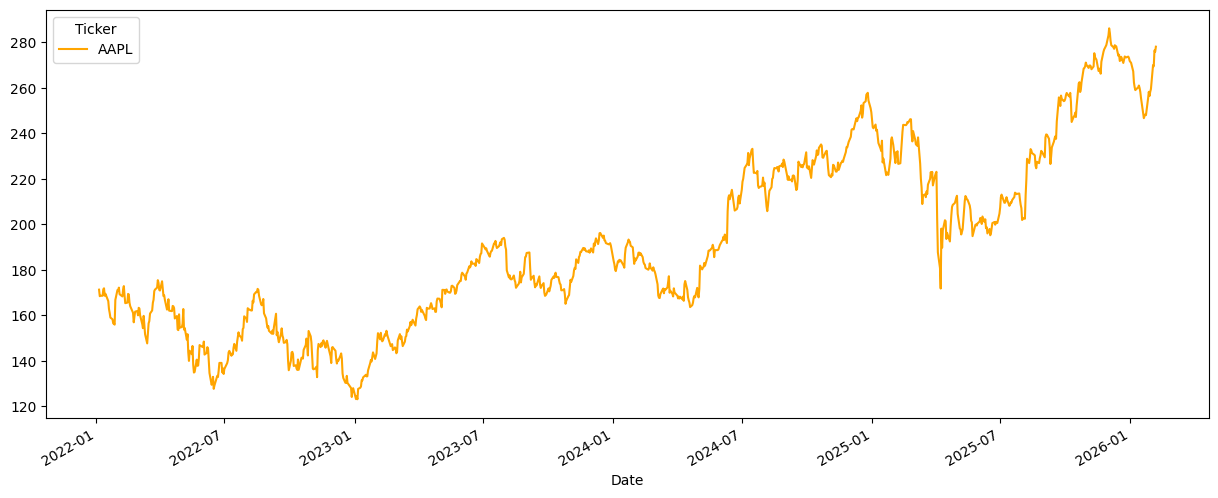

In [6]:
df_aapl['SMA']= df_aapl['Close'].rolling(window=14).mean()
df_aapl['SMA50']= df_aapl['Close'].rolling(window=50).mean()
df_aapl['Close'].plot(figsize=(15,6), color="orange")
df_aapl['SMA'].plot(figsize=(15,6), color="blue")
df_aapl['SMA50'].plot(figsize=(15, 6), color='green')
plt.show()

In [11]:
df_aapl['change'] = (((df_aapl['Close'] - df_aapl['Open'])) / (df_aapl['Open'])*100)
df_fb['change'] = (((df_fb['Close'] - df_fb['Open'])) / (df_fb['Open'])*100)
df_gold['change'] = (((df_gold['Close'] - df_gold['Open'])) / (df_gold['Open'])*100)

df_aapl.tail(5).round(2)

Price,Close,High,Low,Open,Volume,SMA,SMA50,change
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2026-02-02,270.01,270.49,259.21,260.03,73913400,NaN,NaN,NaN
2026-02-03,269.48,271.88,267.61,269.20,64394700,NaN,NaN,NaN
2026-02-04,276.49,278.95,272.29,272.29,90545700,NaN,NaN,NaN
2026-02-05,275.91,279.50,273.23,278.13,52977400,NaN,NaN,NaN
2026-02-06,278.12,280.91,276.93,277.12,50420700,NaN,NaN,NaN


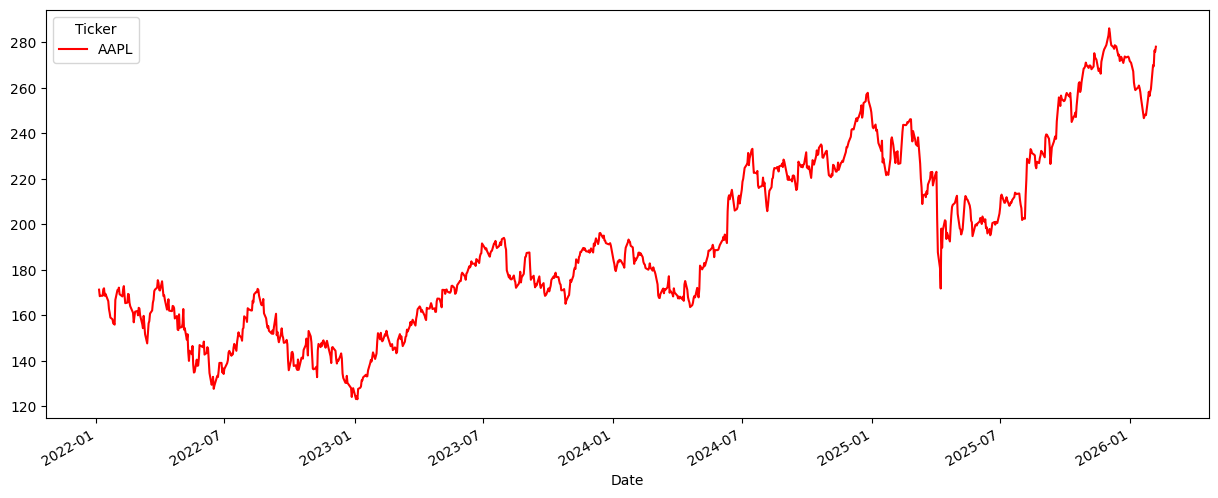

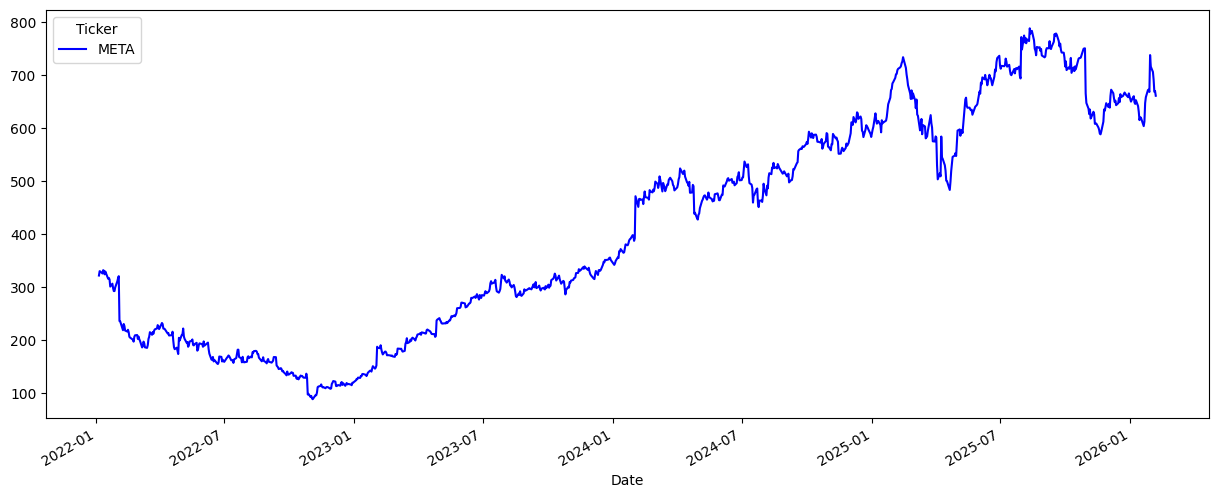

In [13]:
df_aapl['Close'].plot(figsize=(15,6), color="red")
df_fb['Close'].plot(figsize=(15,6), color="blue")
plt.show()

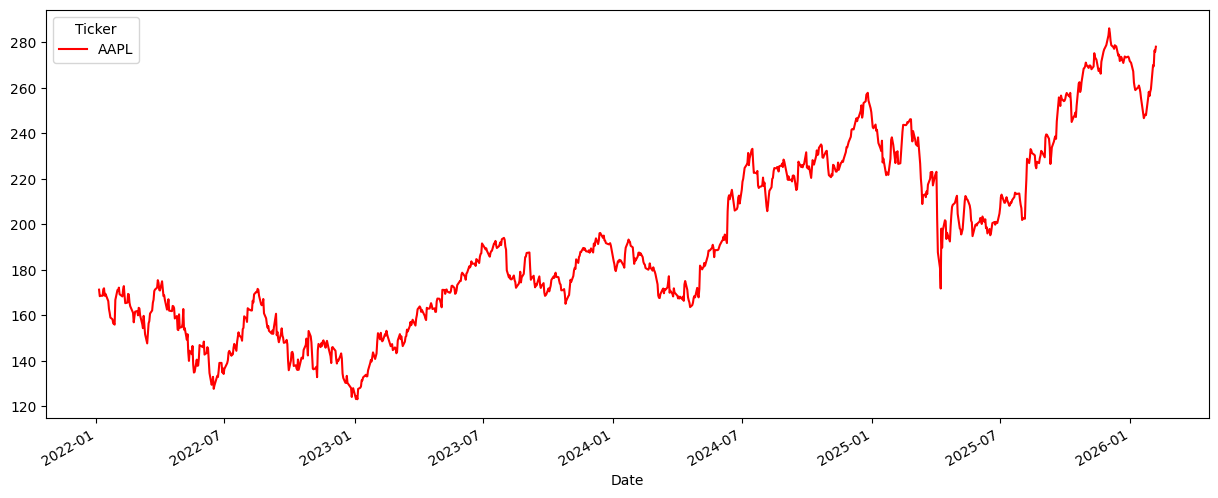

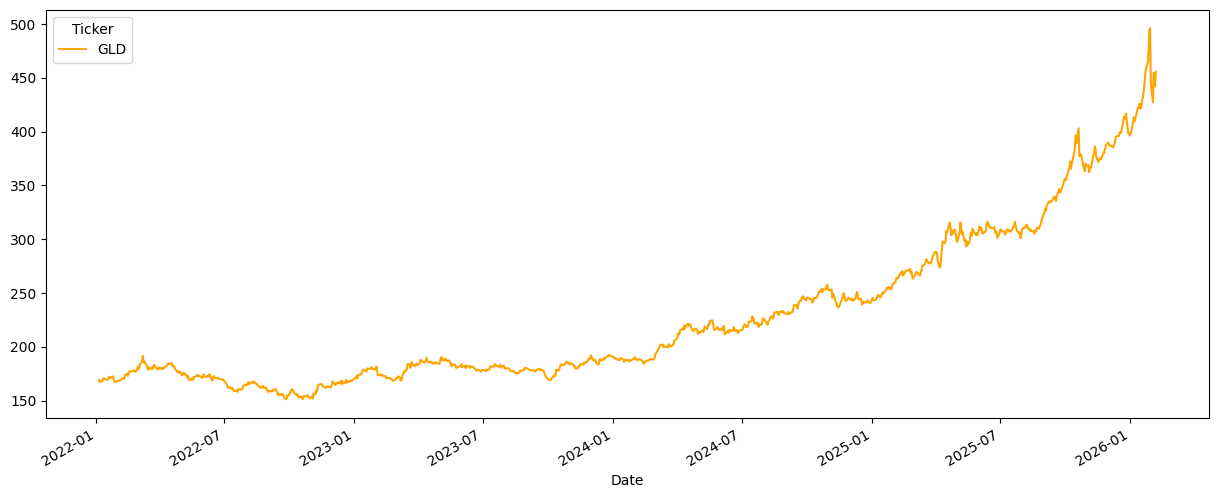

In [22]:
#データマイニング
df_aapl['Close'].plot(figsize=(15,6), color="red")
df_gold['Close'].plot(figsize=(15,6), color="orange")
plt.show()

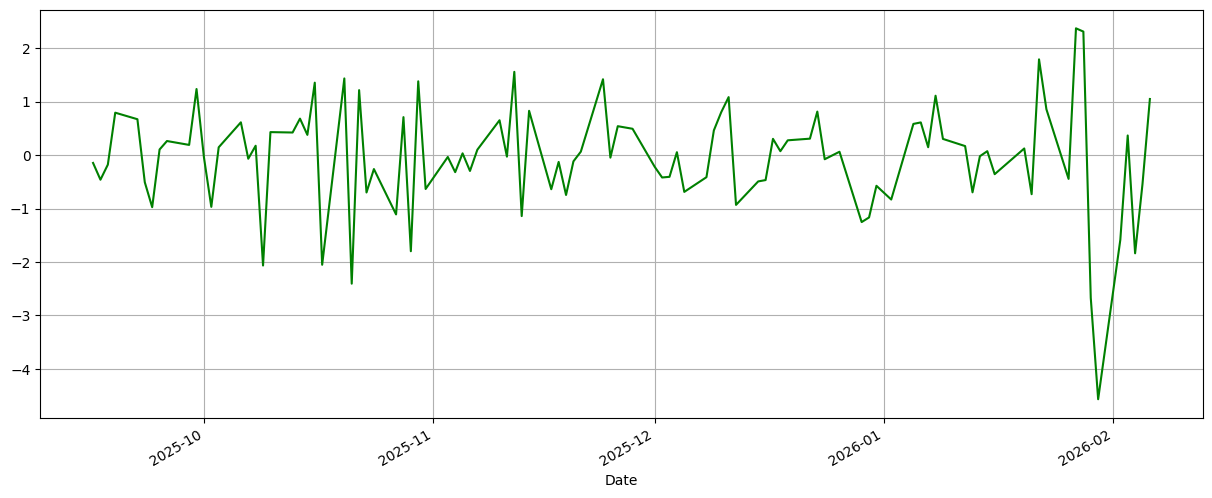

In [24]:
df_aapl['change'].tail(100).plot(grid=True, figsize=(15,6), color="red")
df_fb['change'].tail(100).plot(grid=True, figsize=(15,6), color="blue")
df_gold['change'].tail(100).plot(grid=True, figsize=(15,6), color="green")
plt.show()

In [25]:
df_aapl['label'] = df_aapl['Close'].shift(-30)
df_aapl.tail(35)

Price,Close,High,Low,Open,Volume,SMA,SMA50,change,label
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
2025-12-17,271.839996,276.160004,271.640015,275.010010,50138700,NaN,NaN,NaN,270.010010
2025-12-18,272.190002,273.630005,266.950012,273.609985,51630700,NaN,NaN,NaN,269.480011
2025-12-19,273.670013,274.600006,269.899994,272.149994,144632000,NaN,NaN,NaN,276.489990
2025-12-22,270.970001,273.880005,270.510010,272.859985,36571800,NaN,NaN,NaN,275.910004
2025-12-23,272.359985,272.500000,269.559998,270.839996,29642000,NaN,NaN,NaN,278.119995
2025-12-24,273.809998,275.429993,272.200012,272.339996,17910600,NaN,NaN,NaN,NaN
2025-12-26,273.399994,275.369995,272.859985,274.160004,21521800,NaN,NaN,NaN,NaN
2025-12-29,273.760010,274.359985,272.350006,272.690002,23715200,NaN,NaN,NaN,NaN


In [2]:

X = np.array(df_aapl.drop(['label', 'SMA'], axis=1))
X = sklearn.preprocessing.scale(X)

NameError: name 'np' is not defined

In [3]:
predict_data = X[-30:]

NameError: name 'X' is not defined

In [4]:
X = X[:-30]

NameError: name 'X' is not defined

In [5]:
y = np.array(df_aapl['label'])
y = y[:-30]

NameError: name 'np' is not defined

In [ ]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
X, y, test_size  = 0.2

model = sklearn.linear_model.LinearRegression())
model.fit(X_train,y_train)

accuracy = model.